# 第054讲 特征设计与维度问题

按次序完成四行交互、距离推导、嵌套筛选和稳定性。所有输出为当前内核重新计算。来源与细节见lecture.pdf、lab.pdf、sources.md。

## 1 输入和角色
数据完全合成。前160开发，后200确认；确认标签不得影响排名或k。

In [1]:
import json, numpy as np
from IPython.display import display, Image
import experiment as e
data=np.load(e.ROOT/'data/draws.npz')
print(data['signal_X0'].shape, data['signal_y0'].shape)
print(json.loads((e.ROOT/'data/protocol.json').read_text()))

(360, 80) (360,)
{'n_development': 160, 'n_confirmation': 200, 'features': 80, 'outer_folds': 4, 'inner_folds': 3, 'k_candidates': [2, 5, 15, 40], 'ridge_alpha': 1.0, 'repeats_per_mechanism': 6, 'global_leakage_scope': 'uses all 160 development labels, never 200 confirmation labels', 'split_seed_outer': 540, 'split_seed_inner': 541, 'signal_seeds': [5400, 5401, 5402, 5403, 5404, 5405], 'null_seeds': [5450, 5451, 5452, 5453, 5454, 5455]}


## 2 四行交互与二次列数
先自己手算零相关，再看实际回归输出。

In [2]:
controls=e.controls()
print(controls['interaction'])
for p in [2,10,80]: print('p, quadratic columns excluding constant:',p,p+p*(p+1)//2)

{'X': [[-1.0, -1.0], [-1.0, 1.0], [1.0, -1.0], [1.0, 1.0]], 'y': [1.0, -1.0, -1.0, 1.0], 'correlations': [0.0, 0.0], 'additive_prediction': [-2.220446049250313e-16, 2.220446049250313e-16, -2.220446049250313e-16, 2.220446049250313e-16], 'interaction_prediction': [0.9999999999999998, -0.9999999999999998, -1.0000000000000002, 1.0000000000000002], 'additive_mse': 1.0, 'interaction_mse': 4.930380657631324e-32}
p, quadratic columns excluding constant: 2 5
p, quadratic columns excluding constant: 10 65
p, quadratic columns excluding constant: 80 3320


## 3 距离变异系数
精确推导针对平方距离。模拟端点成对独立，不共用锚点。

In [3]:
for z in controls['distance']:
    print(z['d'], z['mean_squared_distance'], z['cv_squared_distance'], 'theory',z['theory_mean'],z['theory_cv'])

2 4.071783448503645 0.9813952174772141 theory 4 1.0
10 20.013504527965026 0.45387204366841843 theory 20 0.4472135954999579
50 100.56307058122923 0.20141227951631732 theory 100 0.2
200 398.7997041725184 0.10082278844939492 theory 400 0.1


## 4 真实重新运行
这格拟合所有内外层模型。故意错误对照只泄漏开发标签，确认集仍独立。

In [4]:
result=e.run()
e.dump(result,e.ROOT/'outputs/notebook-result.json')
print(json.dumps(result['summary'],ensure_ascii=False,indent=2))

{
  "signal": {
    "nested": {
      "outer_mse": 1.0219372773874318,
      "confirmation_mse": 1.0252444025306442,
      "stability_mean_jaccard": 0.5529100529100529
    },
    "global_leaky": {
      "outer_mse": 0.9870226456530936,
      "confirmation_mse": 1.0252444025306442,
      "stability_mean_jaccard": 0.9444444444444445
    },
    "all_features": {
      "outer_mse": 3.1119835608256867,
      "confirmation_mse": 1.8940603614155755,
      "stability_mean_jaccard": 1.0
    }
  },
  "null": {
    "nested": {
      "outer_mse": 1.1101724344035206,
      "confirmation_mse": 1.0708272896894824,
      "stability_mean_jaccard": 0.13425925925925924
    },
    "global_leaky": {
      "outer_mse": 0.9622039694303419,
      "confirmation_mse": 1.0944609190309478,
      "stability_mean_jaccard": 0.5888888888888888
    },
    "all_features": {
      "outer_mse": 2.9307168051806536,
      "confirmation_mse": 2.031183863424832,
      "stability_mean_jaccard": 1.0
    }
  }
}


## 5 从局部索引回到原行
内层80行不是原表前80行，必须映射外层train_ids。

In [5]:
s=next(z for z in result['runs'] if z['mode']=='signal' and z['rep']==0 and z['method']=='nested')
f=s['folds'][0]
z=f['inner_trials'][0]['folds'][0]
print('outer train/valid:',len(f['train_ids']),len(f['valid_ids']))
print('inner original first 10 IDs:',np.array(f['train_ids'])[z['train_local']][:10])
print('selected columns:',z['selected'])
print('four selected k:',[f['k'] for f in s['folds']])

outer train/valid: 120 40
inner original first 10 IDs: [ 4  7  8 13 14 15 17 18 22 23]
selected columns: [0, 2]
four selected k: [5, 5, 5, 5]


## 6 Jaccard不是因果概率
打印真实每折集合、频率与相似度，不只报告最好一列。

In [6]:
import itertools
sets=[f['selected'] for f in s['folds']]
print('sets',sets)
print('six Jaccard',[e.jaccard(a,b) for a,b in itertools.combinations(sets,2)])
print('first 15 frequency',s['selection_frequency'][:15])

sets [[0, 2, 1, 15, 5], [0, 2, 1, 23, 32], [0, 2, 1, 32, 23], [0, 2, 1, 8, 31]]
six Jaccard [0.42857142857142855, 0.42857142857142855, 0.42857142857142855, 1.0, 0.42857142857142855, 0.42857142857142855]
first 15 frequency [1.0, 1.0, 1.0, 0.0, 0.0, 0.25, 0.0, 0.0, 0.25, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## 7 独立数学审计
按训练边界复算Pearson，用另一种线性代数解法核对预测。

In [7]:
import audit
checks=audit.audit(result)
e.dump(checks,e.ROOT/'outputs/notebook-audit.json')
print(checks)

{'status': 'passed', 'independent_outer_predictions': 144, 'independent_inner_predictions': 1152, 'independent_confirmation_predictions': 36, 'checks': ['manual Pearson ranks at correct boundaries', 'independent ridge solve', 'disjoint splits', 'selected k', 'Jaccard', 'interaction table', 'constant feature', 'shape and NaN errors'], 'limits': ['no proof that selected variables cause y', 'Jaccard not chance adjusted', 'fold stability descriptive, folds dependent']}


## 8 从本次结果重建六图
图4的两类误差对应不同训练行数，不能把差值全归因为泄漏。

In [8]:
import plots
paths=plots.draw(result,e.ROOT/'outputs/notebook-figures')
print([p.name for p in paths])

['01_interaction.png', '02_distance.png', '03_boundaries.png', '04_scores.png', '05_stability.png', '06_frequency.png']


交互真值表

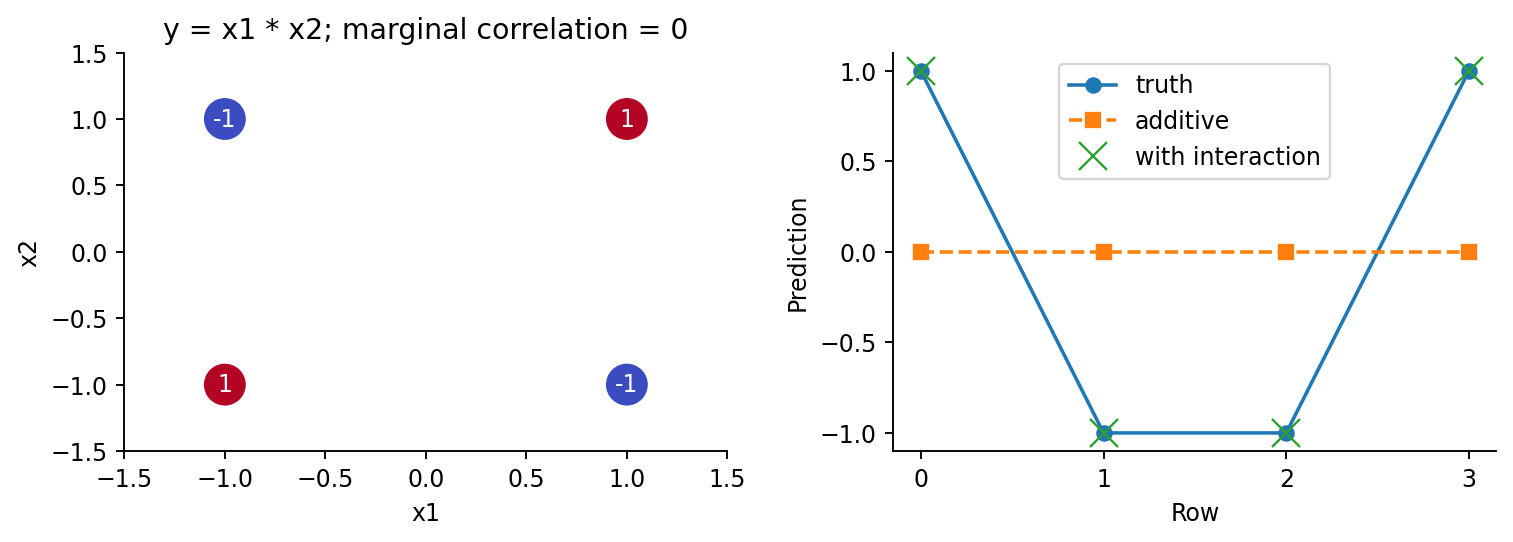

In [9]:
display(Image(filename=str(paths[0])))

平方距离集中

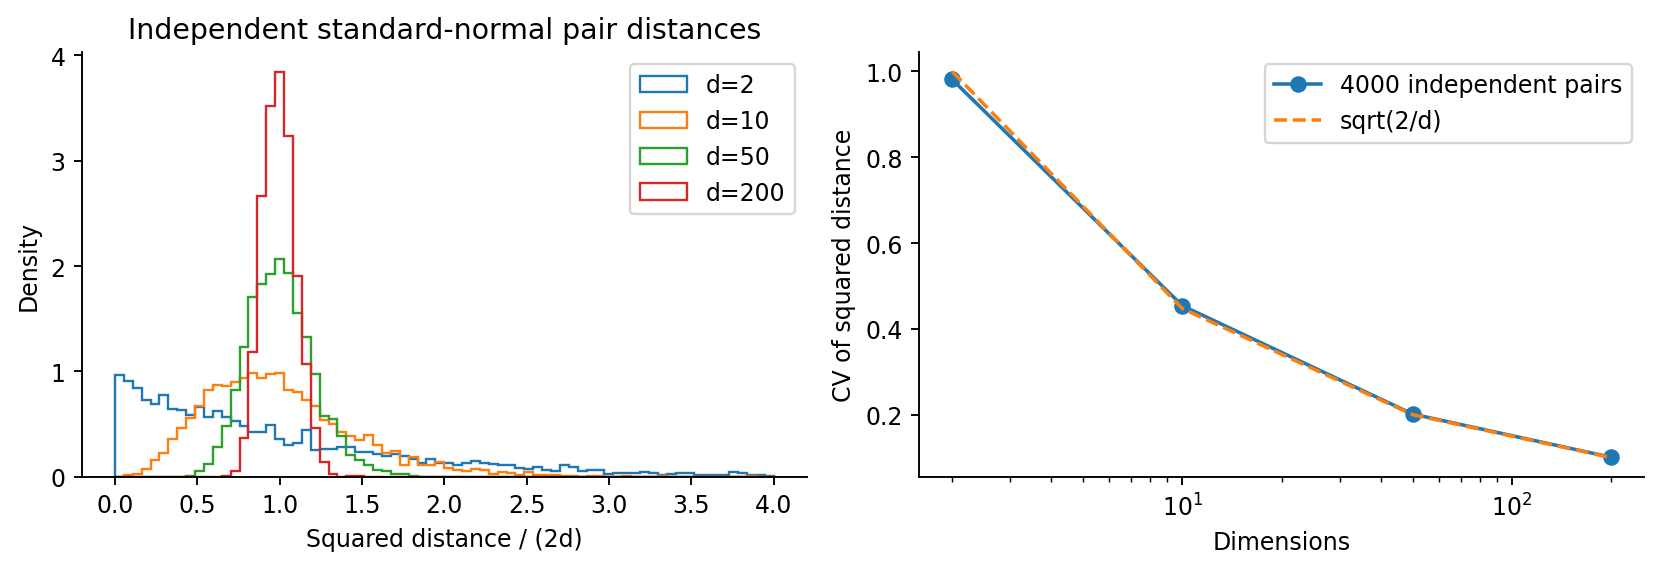

In [10]:
display(Image(filename=str(paths[1])))

嵌套数据边界

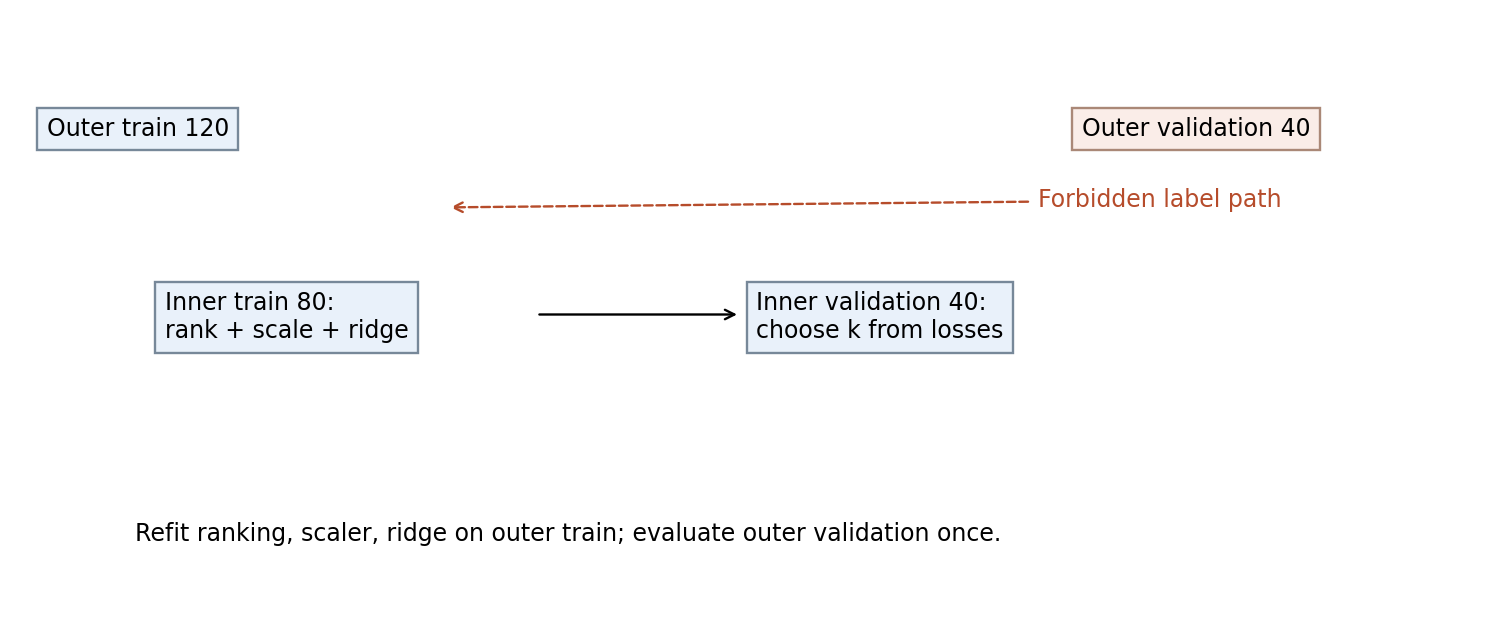

In [11]:
display(Image(filename=str(paths[2])))

CV与独立确认

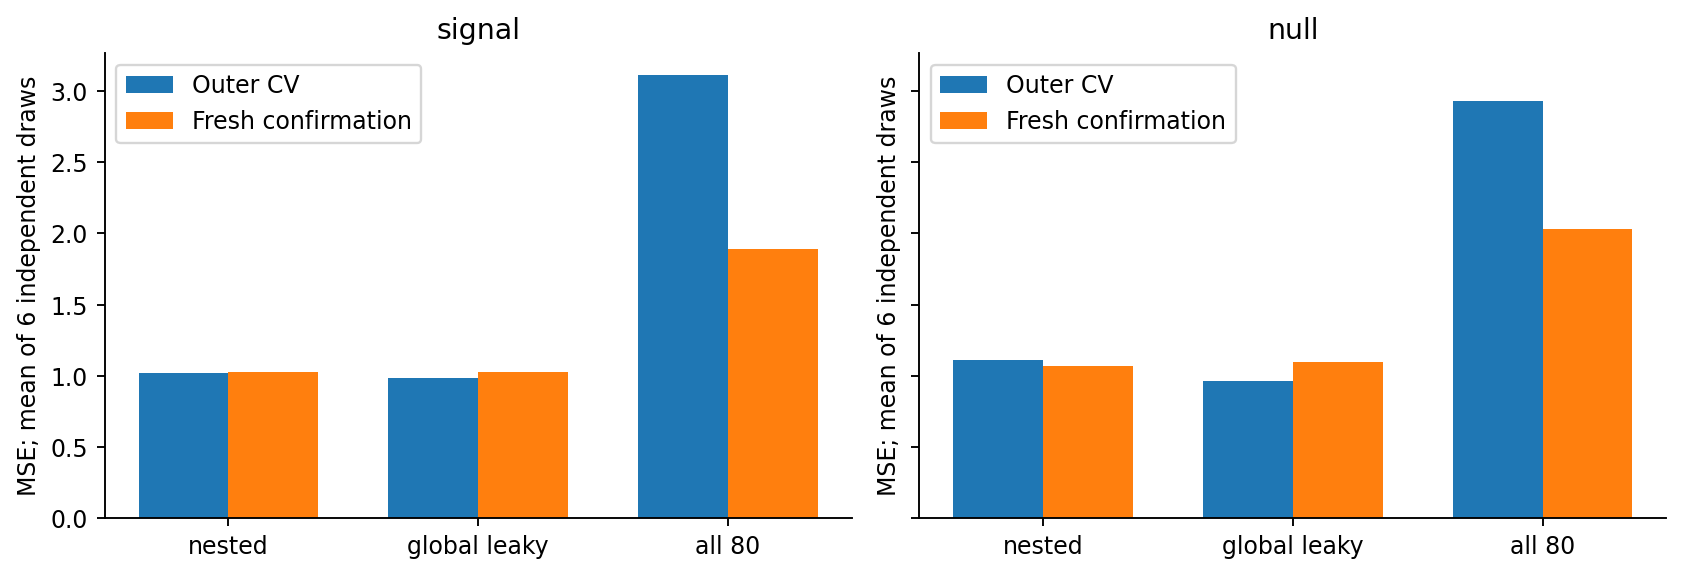

In [12]:
display(Image(filename=str(paths[3])))

集合稳定性

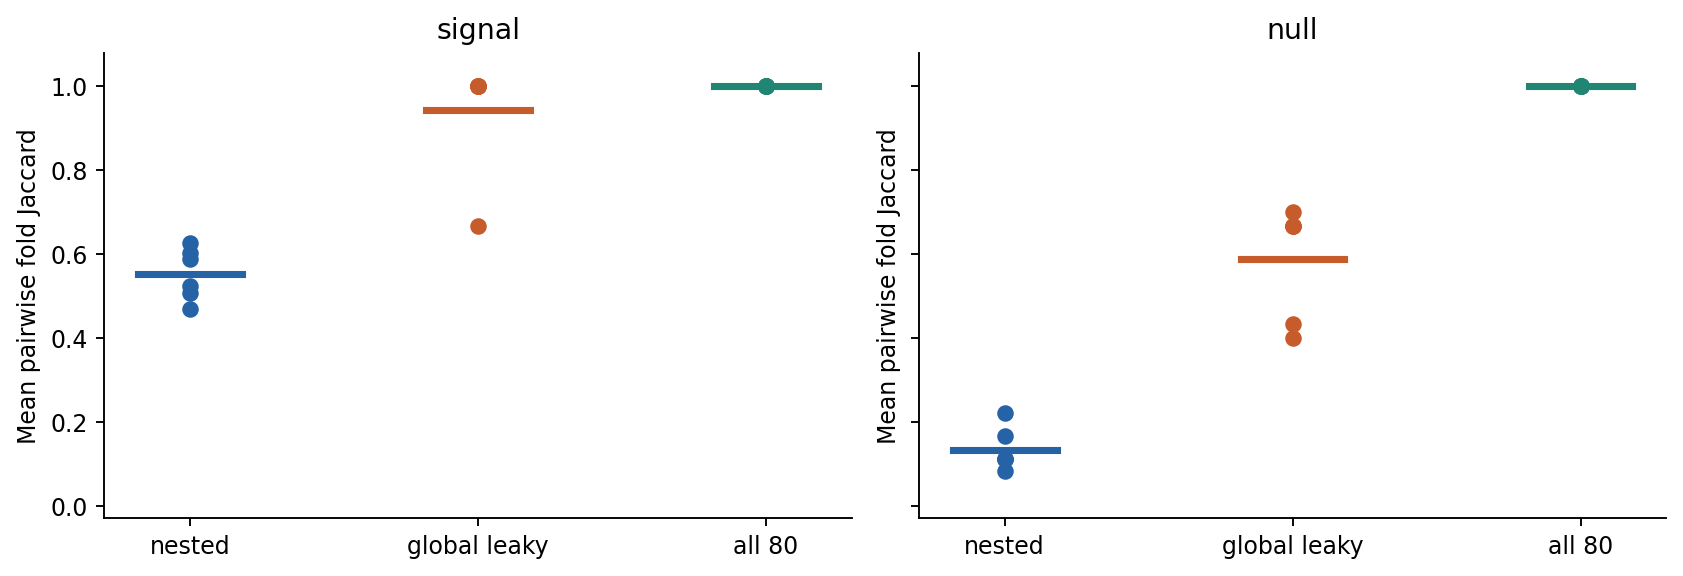

In [13]:
display(Image(filename=str(paths[4])))

选择频率

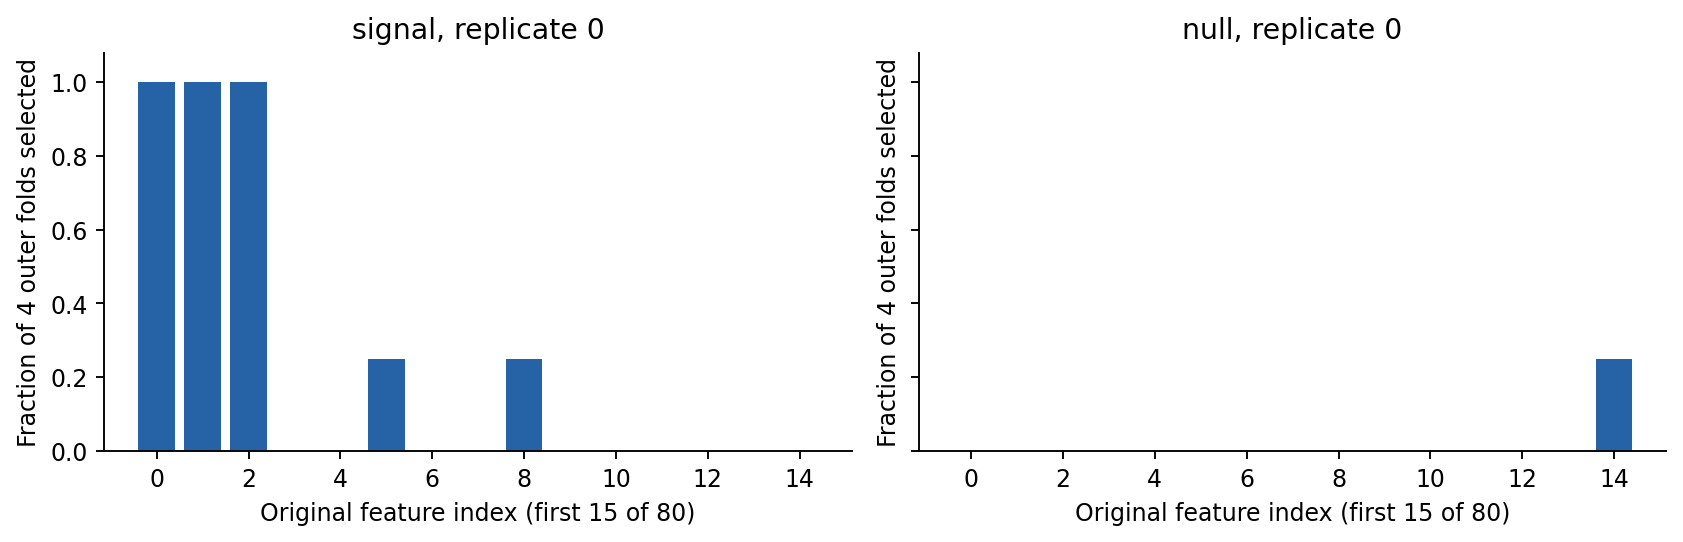

In [14]:
display(Image(filename=str(paths[5])))

## 9 结论练习
为什么全80列稳定性为1却误差较大？为什么signal的两种筛选最终预测相同仍不能为泄漏辩护？先回答，再读answers.pdf。